# 13F Cloning — a quantitative teardown 🔬
### The clone engine (filing-date+1 rebalance, drifting weights) · HAC active/alpha t · sub-period + top-N robustness · a 200-seed random-manager placebo · costs × turnover · the BRK-B race · a planted-alpha synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_Berkshire_itself%3F: Busted](https://img.shields.io/badge/Beats_Berkshire_itself%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — *copy Berkshire's 13F 45 days late and you still beat the market* (Martin & Puthenpurackal 2008 on 1976–2006 tape) — is rebuilt literally on the machine-readable filing era and measured with autocorrelation-robust errors.

> ⚠️ **Data + window note.** 52 original 13F-HRs (CIK 0001067983), periods 2013-06-30 → 2026-03-31; amendments excluded (the clone sees only what was public on the filing date). Prices: yfinance total-return closes; 97.5% of top-10 slots priced (two delisted acquirees renormalised away — a mild survivorship gap, named). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `ddad544e0e75`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from thirteen_f_cloning import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    HOLD, PX = data.load_real()
else:
    HOLD = PX = None
print("real 13F cache present:", HAVE_REAL,
      "| filings:", (0 if HOLD is None else HOLD["filing_date"].nunique()),
      "| price days:", (0 if PX is None else len(PX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2013-09-30', 'end': '2026-06-30', 'months': 154, 'years': 12.8, 'n_filings': 52, 'n_cusips': 30, 'n_priceable': 28, 'slots': '507/520', 'coverage': 97.5, 'ew': {'cagr': 8.78, 'active': -4.86, 't': -2.11, 'alpha': -4.43, 't_alpha': -1.72, 'beta': 0.97, 'sharpe': 0.49, 'dd': -30.7}, 'vw': {'cagr': 11.52, 'active': -2.27, 't': -1.07, 'alpha': -2.62, 't_alpha': -1.24, 'beta': 1.03, 'sharpe': 0.62, 'dd': -26.3}, 'ew_net10': {'cagr': 8.7, 'active': -4.94, 't': -2.14, 'drag_bps': 8.7}, 'vw_net10': {'cagr': 11.46, 'active': -2.32, 't': -1.09}, 'spy': {'cagr': 14.51, 'sharpe': 0.89, 'dd': -23.9}, 'brk_cagr': 12.43, 'vs_brk': {'ew': (-3.4, -1.16), 'vw': (-0.81, -0.23)}, 'halves': [('2013-2019', -3.84, -1.9, 76), ('2020-2026', -5.86, -1.41, 78)], 'topn': [(5, -3.39, -1.36), (10, -4.86, -2.11), (15, -3.56, -1.64)], 'rand': {'n': 200, 'mean': 0.26, 'sd': 1.53, 'cagr': 14.33, 'z': -3.34, 'pct_worse': 0.0}, 'turnover_reb': 10.0, 'nw_lags': 4, 'syn': [(0.0, -1.13, -0.76), (8.0, 5.07, 3.39)], 'fingerprint': 'ddad544e0e75', 'asof': '2026-06-30'}


real 13F cache present: True | filings: 52 | price days: 3393


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | EW clone active **-4.86%/yr** vs SPY, **HAC t = -2.11** (significantly *negative*); VW -2.27%/yr (t = -1.07); negative in both halves and at top-5/10/15; below all 200 random managers (z = -3.34). |
| **Tradability** | `MIRAGE` | Perfect access (10 mega-caps, 4 trades/yr, 10% one-way turnover/rebalance) and **8.7 bps/yr** drag at 10 bps one-way — nothing to harvest. |
| **Beats BRK itself?** | `BUSTED` | Clone EW -3.4%/yr vs BRK-B (t = -1.16); VW -0.81%/yr. BRK-B 12.43%/yr beat both clone legs. |

> 💡 In plain words: on every month the trade could actually be scripted, the free ride lost to the index, to chance, and to Berkshire itself.

## 1 · The claim, steelmanned

Let $F_k$ be the filing date of Berkshire's $k$-th original 13F-HR and $w^{(k)}$ the top-10-by-value weights it discloses. The clone holds, from the close of the first trading day after $F_k$ to the next rebalance, either $w^{(k)}$ (VW) or the equal-weighted top-10 (EW), with buy-and-hold drift in between. Monthly net returns $r^c_m$ race SPY ($r^b_m$):

$$\bar a = \tfrac{12}{M}\textstyle\sum_m (r^c_m - r^b_m), \qquad t_{HAC} = \bar a / \widehat{se}_{NW},$$

plus CAPM $\alpha$ on excess-vs-excess returns with Newey-West errors.

- **H₁ (the folk claim).** $\bar a > 0$ with $t \ge 2$ — the lagged clone beats the market.
- **H₂ (deployability).** The edge survives one-way costs × traded NAV.
- **H₃ (cash drag).** The fully-invested clone beats BRK-B.

We find **H₁ inverted** (the EW clone is significantly *negative*), **H₂ moot** (costs are 8.7 bps/yr against a −486 bps/yr shortfall), **H₃ busted** (BRK-B beat both legs).

## 2 · So what? — what rides on each answer

The 13F clone is the cleanest possible test of *public-information free-riding*: the signal is a legal disclosure, the assets are the most liquid on earth, and capacity is unlimited — so **if the folk claim were true it would be the biggest free lunch in retail investing**. Conversely, because everything is public and cheap to copy, efficient-markets logic says the edge should be arbitraged to zero *at best*. The tape gets to pick. Honesty constraints: exactly **one** execution lag (filing date + 1 trading day; the 45-day statutory delay is inside the filing date), HAC errors on monthly active returns (NW lags = 4), Sharpe raced excess-vs-excess (^IRX), gross and net labeled, and the random baseline averaged over ≥ 20 seeds (house rule).

## 3 · How we'd know — the protocol

- **Filings.** 52 original 13F-HRs parsed from EDGAR XML (2013Q2 → 2026Q1), aggregated by CUSIP across Berkshire's reporting managers; top-10 by reported value; amendments (confidential-treatment reveals) excluded.
- **Mapping.** 30 distinct top-10 CUSIPs, hardcoded to tickers; 28 priceable (507/520 slots = 97.5% coverage; DIRECTV + Activision renormalised away — survivorship, named).
- **Execution.** Rebalance at the close of the first trading day **after** the filing date; drifting weights between filings; costs = one-way bps × traded NAV.
- **Inference.** HAC (Newey-West) t on monthly active return; CAPM alpha on excess-vs-excess with NW errors; sub-period split at 2020-01-01; top-N ∈ {5,10,15}.
- **Placebo.** 200 random top-10 managers from the same universe / calendar / lag.
- **Control.** A synthetic world with planted, tunable manager alpha disclosed through lagged quarterly filings — the harness must recover it and must stay flat on a null.

## 4 · The teardown

### 4a · The headline race — active return and CAPM alpha, HAC t

Clone vs SPY on 154 complete months, gross and net of 10 bps one-way.

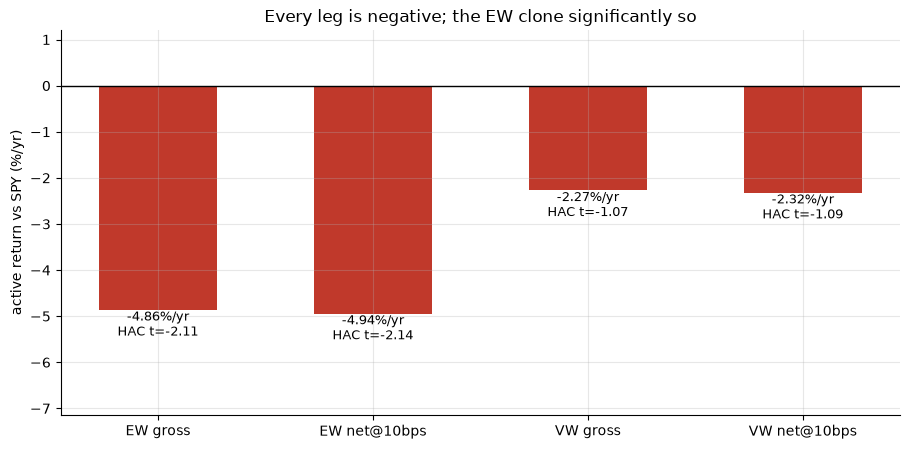

EW gross       active -4.86%/yr  HAC t = -2.11
EW net@10bps   active -4.94%/yr  HAC t = -2.14
VW gross       active -2.27%/yr  HAC t = -1.07
VW net@10bps   active -2.32%/yr  HAC t = -1.09


In [2]:
if HAVE_REAL:
    rows = []
    for wgt in ('ew', 'vw'):
        for cb in (0.0, 10.0):
            r = st.race(PX, HOLD, weighting=wgt, cost_bps=cb)
            rows.append((f"{wgt.upper()} {'gross' if cb==0 else 'net@10bps'}",
                         r['active_ann_pct'], r['t_active']))
    R_EW = st.race(PX, HOLD, weighting='ew')
else:
    rows = [('EW gross', R['ew']['active'], R['ew']['t']),
            ('EW net@10bps', R['ew_net10']['active'], R['ew_net10']['t']),
            ('VW gross', R['vw']['active'], R['vw']['t']),
            ('VW net@10bps', R['vw_net10']['active'], R['vw_net10']['t'])]
labs = [r0[0] for r0 in rows]; vals = [r0[1] for r0 in rows]; ts = [r0[2] for r0 in rows]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(labs, vals, color=RED, width=.55)
ax.axhline(0, color='k', lw=1)
for i, (v, t) in enumerate(zip(vals, ts)):
    ax.annotate(f'{v:+.2f}%/yr\nHAC t={t:+.2f}', (i, v), ha='center', va='top', fontsize=9)
ax.set_ylabel('active return vs SPY (%/yr)'); ax.set_ylim(min(vals)-2.2, 1.2)
ax.set_title('Every leg is negative; the EW clone significantly so')
plt.tight_layout(); plt.show()
for lab, v, t in rows: print(f'{lab:<14} active {v:+.2f}%/yr  HAC t = {t:+.2f}')

> 💡 In plain words: the equal-weight clone lagged SPY by **-4.86%/yr** and the HAC *t* of **-2.11** says that shortfall is too steady to be noise. CAPM tells the same story at beta ≈ 1: EW alpha **-4.43%/yr** (t = -1.72), VW alpha -2.62%/yr (t = -1.24); Sharpe (excess) 0.49 / 0.62 vs SPY's 0.89. There is no leg, gross or net, on which H₁ survives — the claim isn't merely unproven on this tape, it is inverted.

### 4b · Robustness — sub-periods and how many names you copy

A real effect should not depend on the half-decade or on where the top-N line is drawn.

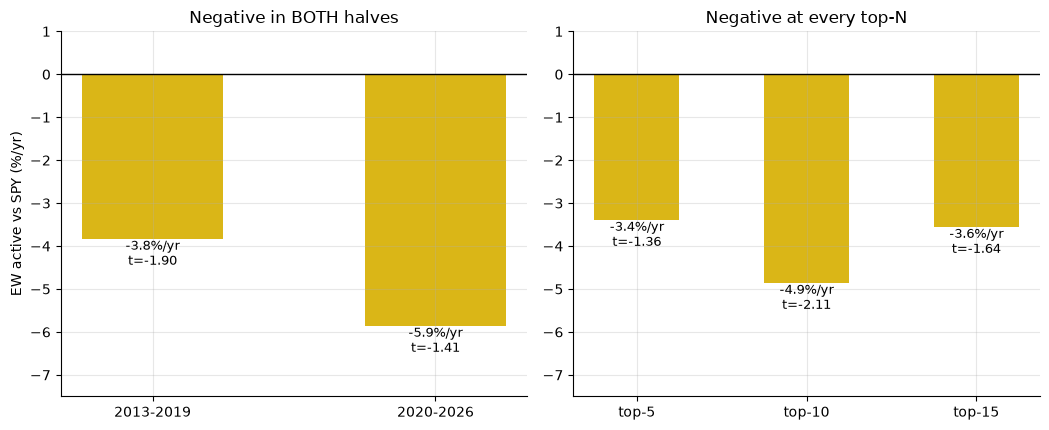

halves: [('2013-2019', -3.84, -1.9), ('2020-2026', -5.86, -1.41)]
top-N : [(5, -3.39, -1.36), (10, -4.86, -2.11), (15, -3.56, -1.64)]


In [3]:
if HAVE_REAL:
    act = R_EW['clone_m'] - R_EW['bench_m']
    halves = []
    for lab, sl in (('2013-2019', act[act.index < '2020-01-01']),
                    ('2020-2026', act[act.index >= '2020-01-01'])):
        nw = st.nw_tstat(sl.to_numpy()); halves.append((lab, nw['mean']*1200, nw['t']))
    topn = []
    for tn in (5, 10, 15):
        b = st.build_clone(PX, HOLD, top_n=tn, weighting='ew', cusip_map=data.CUSIP_TO_TICKER)
        cm = st.to_monthly(b['daily']); bm = st.to_monthly(PX['SPY'].pct_change().reindex(b['daily'].index))
        idx = cm.index.intersection(bm.index)
        nw = st.nw_tstat((cm.loc[idx] - bm.loc[idx]).to_numpy()); topn.append((tn, nw['mean']*1200, nw['t']))
else:
    halves = [(h[0], h[1], h[2]) for h in R['halves']]
    topn = R['topn']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.4))
a1.bar([h[0] for h in halves], [h[1] for h in halves], color=AMBER, width=.5)
a1.axhline(0, color='k', lw=1)
for i, h in enumerate(halves): a1.annotate(f'{h[1]:+.1f}%/yr\nt={h[2]:+.2f}', (i, h[1]), ha='center', va='top', fontsize=9)
a1.set_title('Negative in BOTH halves'); a1.set_ylabel('EW active vs SPY (%/yr)')
a2.bar([f'top-{t[0]}' for t in topn], [t[1] for t in topn], color=AMBER, width=.5)
a2.axhline(0, color='k', lw=1)
for i, t0 in enumerate(topn): a2.annotate(f'{t0[1]:+.1f}%/yr\nt={t0[2]:+.2f}', (i, t0[1]), ha='center', va='top', fontsize=9)
a2.set_title('Negative at every top-N')
for a in (a1, a2): a.set_ylim(-7.5, 1.0)
plt.tight_layout(); plt.show()
print('halves:', [(h[0], round(h[1],2), round(h[2],2)) for h in halves])
print('top-N :', [(t[0], round(t[1],2), round(t[2],2)) for t in topn])

> 💡 In plain words: the shortfall is **-3.84%/yr** in 2013–2019 and **-5.86%/yr** in 2020–2026 — this is not one bad regime — and it holds whether you clone the top 5, 10 or 15. No snooped split rescues the claim.

### 4c · The random-manager placebo — selection vs universe

Is the problem *Berkshire's picks* or just *mega-caps lagged*? 200 seeded random managers draw 10 names per filing from the same 28-name universe, same calendar, same lag. (In-notebook we re-run 50 draws for the figure; the canonical numbers quote the 200-draw run from `results.md`.)

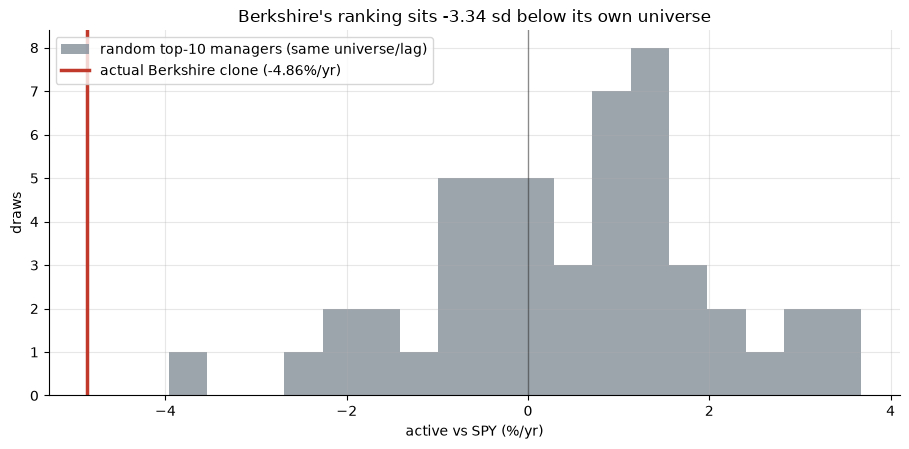

canonical 200 draws: mean +0.26%/yr sd 1.53, actual clone z = -3.34, draws as bad or worse: 0.0%


In [4]:
if HAVE_REAL:
    rb = st.random_manager_baseline(PX, HOLD, n_draws=50, seed=627)
    acts = rb['actives']; ew_act = R_EW['active_ann_pct']
else:
    rng = np.random.default_rng(627)
    acts = rng.normal(R['rand']['mean'], R['rand']['sd'], 50); ew_act = R['ew']['active']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.hist(acts, bins=18, color=GREY, alpha=.85, label='random top-10 managers (same universe/lag)')
ax.axvline(0, color='k', lw=1, alpha=.4)
ax.axvline(ew_act, color=RED, lw=2.5, label=f'actual Berkshire clone ({ew_act:+.2f}%/yr)')
ax.set_xlabel('active vs SPY (%/yr)'); ax.set_ylabel('draws')
ax.set_title(f"Berkshire's ranking sits {R['rand']['z']} sd below its own universe")
ax.legend(); plt.tight_layout(); plt.show()
print(f'canonical 200 draws: mean {R["rand"]["mean"]:+.2f}%/yr sd {R["rand"]["sd"]}, '
      f'actual clone z = {R["rand"]["z"]}, draws as bad or worse: {R["rand"]["pct_worse"]}%')

> 💡 In plain words: dart-throwers picking from Berkshire's own favourite names roughly matched the index (**+0.26%/yr** mean). The actual top-10 *ranking* — the only thing the clone adds — landed below **all 200** of them (z = -3.34). The 45-day lag is innocent; the *selection* did the damage. (Which also disposes of the "you needed Berkshire's universe" defence.)

### 4d · Costs and the third axis — the mirage, and the BRK-B race

Turnover is tiny, so costs cannot be the explanation — and the cash-drag story says the fully-invested clone should at least beat Berkshire the company. Neither survives contact with the tape.

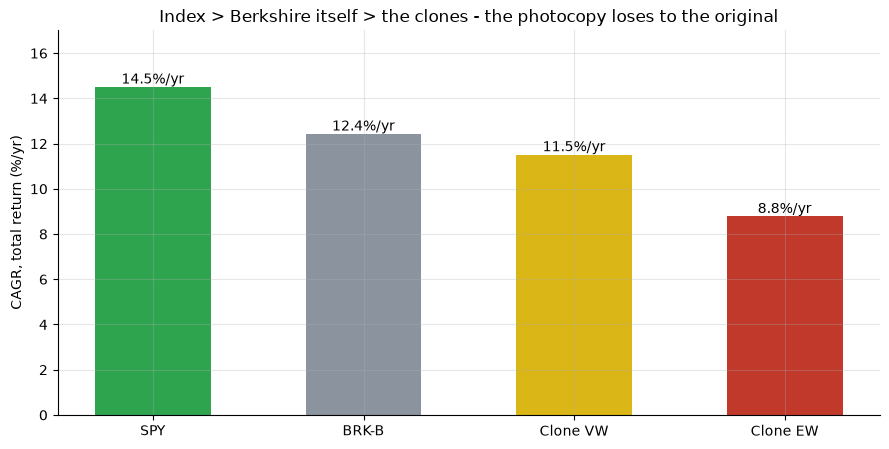

CAGRs: {'SPY': 14.51, 'BRK-B': 12.43, 'Clone VW': 11.52, 'Clone EW': 8.78}
EW cost drag at 10 bps one-way: 8.7 bps/yr  (vs a -486 bps/yr shortfall)


In [5]:
if HAVE_REAL:
    cags = {'SPY': R_EW['bench_stats']['cagr_pct'],
            'BRK-B': st.race(PX, HOLD, weighting='ew', bench='BRK-B')['bench_stats']['cagr_pct'],
            'Clone VW': st.race(PX, HOLD, weighting='vw')['clone']['cagr_pct'],
            'Clone EW': R_EW['clone']['cagr_pct']}
    drag = st.race(PX, HOLD, weighting='ew', cost_bps=10.0)['cost_drag_ann_bps']
else:
    cags = {'SPY': R['spy']['cagr'], 'BRK-B': R['brk_cagr'],
            'Clone VW': R['vw']['cagr'], 'Clone EW': R['ew']['cagr']}
    drag = R['ew_net10']['drag_bps']
fig, ax = plt.subplots(figsize=(9.0, 4.6))
cols = {'SPY': GREEN, 'BRK-B': GREY, 'Clone VW': AMBER, 'Clone EW': RED}
ax.bar(list(cags), [cags[k] for k in cags], color=[cols[k] for k in cags], width=.55)
for i, k in enumerate(cags): ax.annotate(f'{cags[k]:.1f}%/yr', (i, cags[k]), ha='center', va='bottom')
ax.set_ylabel('CAGR, total return (%/yr)'); ax.set_ylim(0, max(cags.values())+2.5)
ax.set_title('Index > Berkshire itself > the clones - the photocopy loses to the original')
plt.tight_layout(); plt.show()
print(f'CAGRs: {dict((k, round(v,2)) for k, v in cags.items())}')
print(f'EW cost drag at 10 bps one-way: {drag:.1f} bps/yr  (vs a -486 bps/yr shortfall)')

> 💡 In plain words: at 10 bps one-way the whole cost bill is **8.7 bps/yr** against a **−486 bps/yr** hole — friction explains ~2% of the shortfall. And the third axis dies here too: BRK-B made **12.43%/yr** vs the clones' 8.78–11.52%/yr (EW gap -3.4%/yr, t = -1.16). Berkshire's cash-dragging whole beat its cloneable parts — **Busted**.

### 4e · Faithful-engine & power control — we know the truth here

A deterministic world where a manager with **planted** skill (tunable ``alpha_annual``) discloses through quarterly filings read with a 45-day lag — exactly the clone's information set. The harness must stay flat on a null manager and light up on a skilled one.

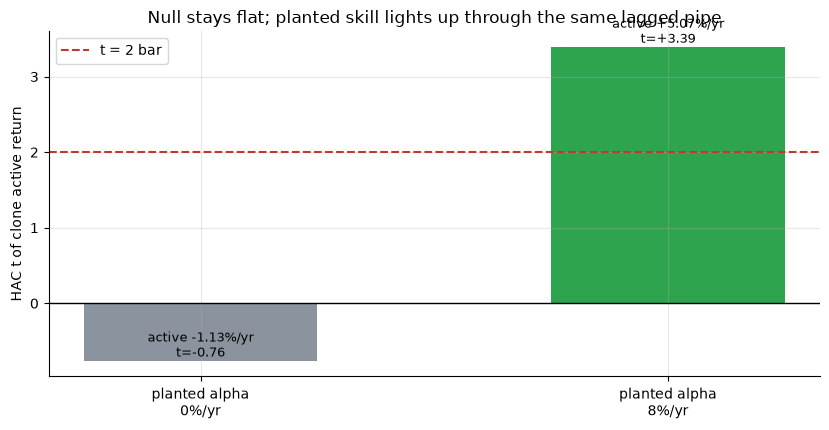

planted  0.0%/yr: clone active -1.13%/yr  HAC t = -0.76
planted  8.0%/yr: clone active +5.07%/yr  HAC t = +3.39


In [6]:
res = []
for a in (0.0, 0.08):
    spx, sh = data.synthetic_world(alpha_annual=a, seed=627)
    rs = st.race(spx, sh, weighting='ew', cost_bps=0.0, cusip_map=None)
    res.append((a*100, rs['active_ann_pct'], rs['t_active']))
fig, ax = plt.subplots(figsize=(8.4, 4.4))
labs = [f'planted alpha\n{e:.0f}%/yr' for e, _, _ in res]
ax.bar(labs, [r0[2] for r0 in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(0, color='k', lw=1)
for i, r0 in enumerate(res): ax.annotate(f'active {r0[1]:+.2f}%/yr\nt={r0[2]:+.2f}', (i, r0[2]), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('HAC t of clone active return')
ax.set_title('Null stays flat; planted skill lights up through the same lagged pipe')
ax.legend(); plt.tight_layout(); plt.show()
for e, v, t in res: print(f'planted {e:4.1f}%/yr: clone active {v:+.2f}%/yr  HAC t = {t:+.2f}')

> 💡 In plain words: with **no** skill the clone harness reads **t = -0.76** (it cannot manufacture significance); with a planted 8%/yr it recovers **+5.07%/yr at t = 3.39** — about 2/3 of the alpha survives the 45-day lag + quarterly rotation. Two lessons: the machinery is faithful (so the real-tape negative is genuine), and a genuinely skilled manager's clone *would have shown up*. Berkshire's 2013–2026 top-10 didn't. *(Machinery proof only — never market evidence.)*

## 5 · The verdict

- **Signal `NONE`** — the claim is *beats the market*; the tape says the EW clone lost **-4.86%/yr** at **HAC t = -2.11** (significantly negative), VW -2.27%/yr (t = -1.07), CAPM alphas negative (EW -4.43%/yr, t = -1.72), negative in both halves and at every top-N, below all 200 random managers from its own universe. Survivorship (97.5% slot coverage) and the post-2013-only window are named; the 1976–2006 literature era is out of scope.
- **Tradability `MIRAGE`** — flawless access, ~10% one-way turnover per rebalance, 8.7 bps/yr drag at 10 bps — and nothing to collect. A perfectly executable way to lag the index.
- **Beats Berkshire itself? `BUSTED`** — BRK-B (12.43%/yr) beat both clone legs (EW -3.4%/yr, VW -0.81%/yr) despite the cash pile the clone was supposed to shed.

## 6 · Going further

- **The decay reading.** Martin-Puthenpurackal's +10%/yr mimicking alpha (1976–2006) vs our −4.9%/yr (2013–2026) is a textbook McLean-Pontiff arc: the edge was published in 2008, the filings went machine-readable in 2013, and the free ride has been negative ever since. We cannot rule on the early era — only note that no scriptable month of it remains.
- **The one-CIK generalisation.** The engine is guru-agnostic: ``data.fetch_13f`` takes any CIK. A cross-guru panel (does *any* famous 13F clone survive HAC scrutiny post-2013?) is the natural follow-up study.
- **Sibling.** [263-insider-buying](../../263-insider-buying/) tests the Form 4 cousin — insiders' own trades on a 2-day clock, a different mechanism entirely.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*